In [315]:
import pickle
import pandas as pd

tcn_bigru = pickle.load(open("results_tcn_bigru.pkl", "rb"))
tcn       = pickle.load(open("results_tcn.pkl", "rb"))
bigru     = pickle.load(open("results_bigru.pkl", "rb"))

# Langsung pakai
metrics_data = {
    "Model": ["TCN-BiGRU", "TCN", "BiGRU"],
    "RMSE":  [tcn_bigru["rmse"],  tcn["rmse"],  bigru["rmse"]],
    "MAE":   [tcn_bigru["mae"],   tcn["mae"],   bigru["mae"]],
    "MAPE":  [tcn_bigru["mape"],  tcn["mape"],  bigru["mape"]],
    "R²":    [tcn_bigru["r2"],    tcn["r2"],    bigru["r2"]],
}

forecast_h1 = {
    "Model":        ["TCN-BiGRU", "TCN", "BiGRU"],
    "Forecast H+1": [tcn_bigru["forecast_h1"], tcn["forecast_h1"], bigru["forecast_h1"]],
}

forecast_dates        = pd.to_datetime(tcn_bigru["forecast_30_dates"])  # tanggal sama semua
forecast_30_tcn_bigru = tcn_bigru["forecast_30_prices"]
forecast_30_tcn       = tcn["forecast_30_prices"]
forecast_30_bigru     = bigru["forecast_30_prices"]

best_splits = {
    "TCN-BiGRU":  tcn_bigru["best_split"],
    "TCN":   tcn["best_split"],
    "BiGRU": bigru["best_split"],
}

last_actual_price = tcn_bigru["last_actual_price"]
last_actual_date  = tcn_bigru["last_actual_date"]

TABEL RANGKUMAN AKHIR — SEMUA MODEL

In [316]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df_summary_final = pd.DataFrame([
    {
        "Model":        "TCN-BiGRU",
        "Best Split":   str(tcn_bigru["best_split"]),
        "RMSE":         round(tcn_bigru["rmse"], 4),
        "MAE":          round(tcn_bigru["mae"], 4),
        "MAPE (%)":     round(tcn_bigru["mape"], 4),
        "R²":           round(tcn_bigru["r2"], 4),
        "Forecast H+1": round(tcn_bigru["forecast_h1"], 3),
        "Total Training Time (detik)": round(tcn_bigru["total_time"], 2),
    },
    {
        "Model":        "TCN",
        "Best Split":   str(tcn["best_split"]),
        "RMSE":         round(tcn["rmse"], 4),
        "MAE":          round(tcn["mae"], 4),
        "MAPE (%)":     round(tcn["mape"], 4),
        "R²":           round(tcn["r2"], 4),
        "Forecast H+1": round(tcn["forecast_h1"], 3),
        "Total Training Time (detik)": round(tcn["total_time"], 2),
    },
    {
        "Model":        "BiGRU",
        "Best Split":   str(bigru["best_split"]),
        "RMSE":         round(bigru["rmse"], 4),
        "MAE":          round(bigru["mae"], 4),
        "MAPE (%)":     round(bigru["mape"], 4),
        "R²":           round(bigru["r2"], 4),
        "Forecast H+1": round(bigru["forecast_h1"], 3),
        "Total Training Time (detik)": round(bigru["total_time"], 2),
    },
])

print("=" * 70)
print("TABEL RANGKUMAN AKHIR — SEMUA MODEL")
print("=" * 70)
display(df_summary_final)

TABEL RANGKUMAN AKHIR — SEMUA MODEL


,Model,Best Split,RMSE,MAE,MAPE (%),R²,Forecast H+1,Total Training Time (detik)
0,TCN-BiGRU,"(0.6, 0.2, 0.2)",107.9500,76.3110,1.0625,0.9782,7167.005859,5591.95
1,TCN,"(0.6, 0.2, 0.2)",108.3722,76.7790,1.0699,0.9780,7148.627930,1190.96
2,BiGRU,"(0.6, 0.2, 0.2)",107.6649,76.2405,1.0610,0.9783,7171.730957,5429.67


ini total trainingnya jgn dipake, pakenya running time milik kombinasi tsb

BAR CHART METRIK


FORECAST H+1 MASING-MASING MODEL


,Model,Forecast H+1 (Rp)
0,TCN-BiGRU,7167
1,TCN,7149
2,BiGRU,7172


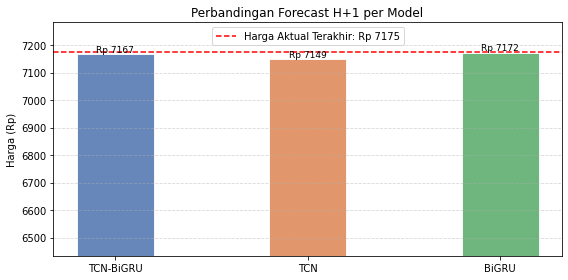

In [317]:
# ===============================
# TABEL + CHART FORECAST H+1
# ===============================
df_h1 = pd.DataFrame(forecast_h1)
df_h1 = df_h1.rename(columns={"Forecast H+1": "Forecast H+1 (Rp)"})
df_h1["Forecast H+1 (Rp)"] = df_h1["Forecast H+1 (Rp)"].map(lambda x: f"{x:.0f}")
print("\n" + "=" * 40)
print("FORECAST H+1 MASING-MASING MODEL")
print("=" * 40)
display(df_h1)

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(forecast_h1["Model"], forecast_h1["Forecast H+1"],
              color=colors, alpha=0.85, edgecolor='white', width=0.4)

ax.axhline(y=last_actual_price, color='red', linestyle='--', linewidth=1.5,
           label=f'Harga Aktual Terakhir: Rp {last_actual_price}')

for bar, val in zip(bars, forecast_h1["Forecast H+1"]):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + (max(forecast_h1["Forecast H+1"]) - min(forecast_h1["Forecast H+1"])) * 0.05,
            f"Rp {val:.0f}", ha='center', va='bottom', fontsize=9)

# ← INI KUNCINYA: set ylim mulai dari sedikit di bawah nilai terendah
all_values = forecast_h1["Forecast H+1"] + [last_actual_price]
y_min = min(all_values) * 0.9   # 9% di bawah nilai terkecil
y_max = max(all_values) * 1.015   # 1.5% di atas nilai terbesar
ax.set_ylim(y_min, y_max)

ax.set_title("Perbandingan Forecast H+1 per Model")
ax.set_ylabel("Harga (Rp)")
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

Perbandingan Metrik Antar Model

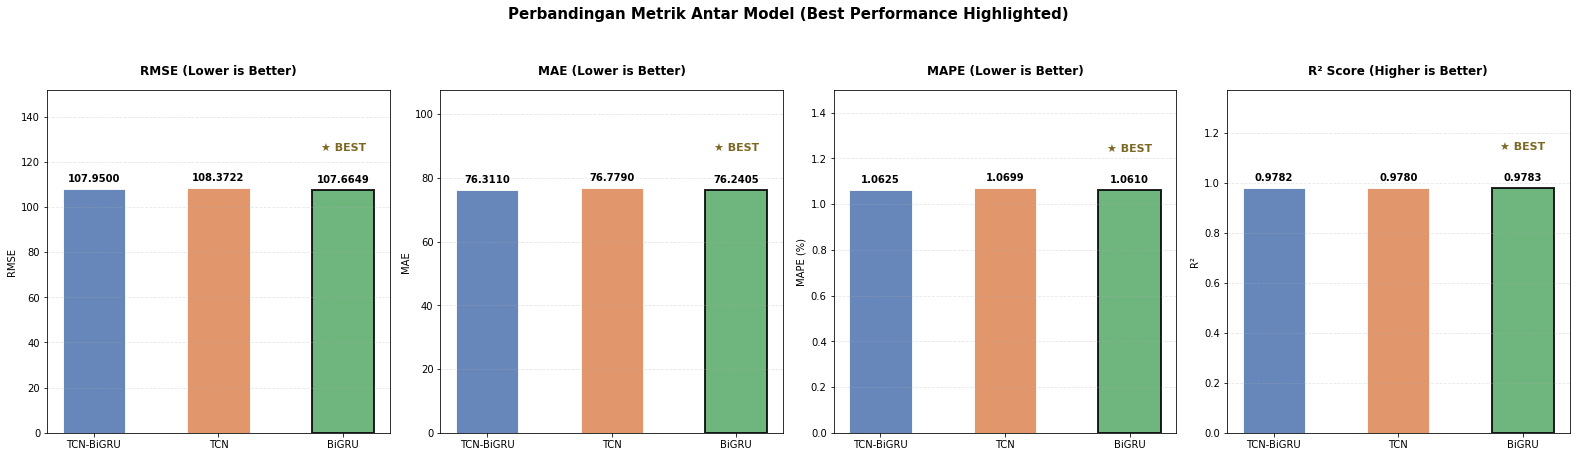

In [318]:
import numpy as np
import matplotlib.pyplot as plt

models  = ["TCN-BiGRU", "TCN", "BiGRU"]
colors  = ["#4C72B0", "#DD8452", "#55A868"]
x       = np.arange(len(models))
width   = 0.5

# Data dummy (pastikan variabel asli Anda sudah terdefinisi)
metric_info = [
    ("RMSE",     [tcn_bigru["rmse"],  tcn["rmse"],  bigru["rmse"]],  "RMSE (Lower is Better)"),
    ("MAE",      [tcn_bigru["mae"],   tcn["mae"],   bigru["mae"]],   "MAE (Lower is Better)"),
    ("MAPE (%)", [tcn_bigru["mape"],  tcn["mape"],  bigru["mape"]],  "MAPE (Lower is Better)"),
    ("R²",       [tcn_bigru["r2"],    tcn["r2"],    bigru["r2"]],    "R² Score (Higher is Better)"),
]

fig, axes = plt.subplots(1, 4, figsize=(22, 6))
fig.suptitle("Perbandingan Metrik Antar Model (Best Performance Highlighted)", fontsize=15, fontweight='bold', y=1.05)

for ax, (ylabel, values, title) in zip(axes, metric_info):
    bars = ax.bar(models, values, color=colors, alpha=0.85, edgecolor='white', width=width)
    
    # 1. Tentukan indeks "Best" berdasarkan jenis metrik
    if ylabel == "R²":
        best_idx = np.argmax(values) # R2 makin besar makin bagus
    else:
        best_idx = np.argmin(values) # RMSE, MAE, MAPE makin kecil makin bagus

    # 2. Styling bar terbaik
    bars[best_idx].set_edgecolor('black')
    bars[best_idx].set_linewidth(2)

    # 3. Tambahkan Teks Nilai dan Bintang
    max_val = max(values)
    for i, (bar, val) in enumerate(zip(bars, values)):
        # Teks angka di atas bar
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + (max_val * 0.02),
                f"{val:.4f}", ha='center', va='bottom', 
                fontsize=10, fontweight='bold')
        
        # Tambahkan ★ BEST hanya di bar terbaik
        if i == best_idx:
            ax.text(bar.get_x() + bar.get_width()/2,
                    bar.get_height() + (max_val * 0.15),
                    "★ BEST", ha='center', va='bottom',
                    fontsize=11, fontweight='bold', color="#7D6823")

    # 4. Final Touch
    ax.set_title(title, fontsize=12, fontweight='bold', pad=15)
    ax.set_ylabel(ylabel, fontsize=10)
    ax.set_ylim(0, max_val * 1.4) # Beri ruang lebih untuk bintang
    ax.grid(axis='y', linestyle='--', alpha=0.3)
    ax.tick_params(axis='x', labelsize=10)

plt.tight_layout()
plt.show()

jangan menggambarkan di frame yang sama, nnti dianggap skalanya jadi sama

ANALISIS TIME PROCESS

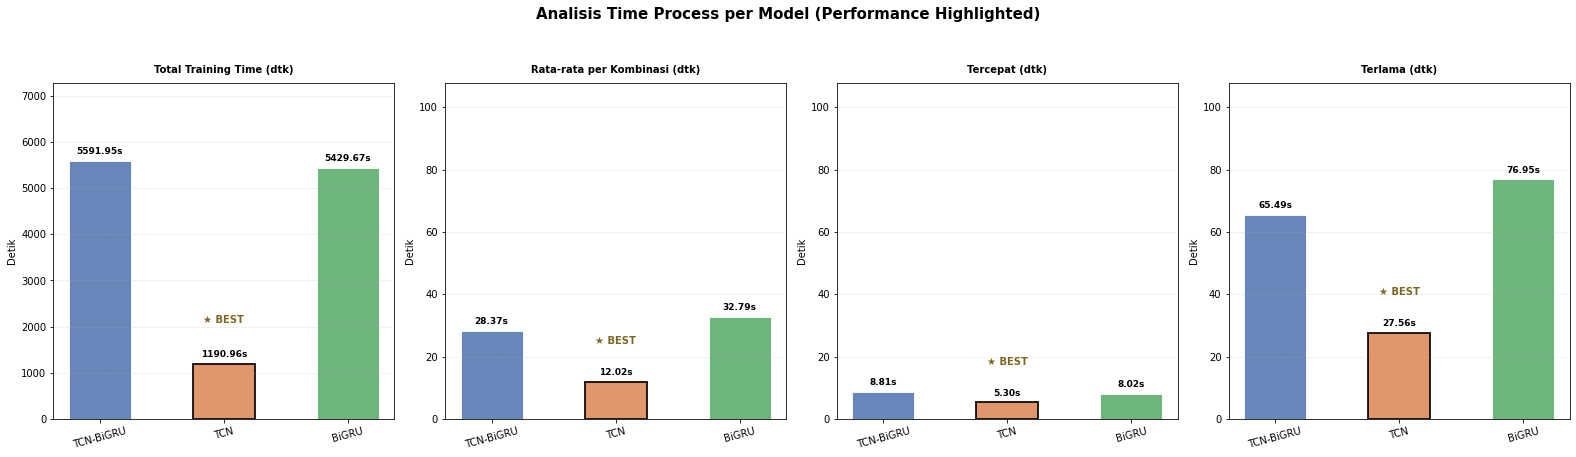

In [319]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1. Update Fungsi Statistik (Total Time dalam Detik)
def time_stats(pkl, model_name):
    times = pkl["tuning_times"]
    return {
        "Model":                          model_name,
        "Total Training Time (dtk)":      round(pkl["total_time"], 2), # Diubah ke detik
        "Rata-rata per Kombinasi (dtk)":  round(np.mean(times), 2),
        "Tercepat (dtk)":                  round(np.min(times), 2),
        "Terlama (dtk)":                   round(np.max(times), 2),
        "Jumlah Kombinasi":                len(times),
    }

df_time = pd.DataFrame([
    time_stats(tcn_bigru, "TCN-BiGRU"),
    time_stats(tcn,       "TCN"),
    time_stats(bigru,     "BiGRU"),
])

# --- HITUNG SKALA Y GLOBAL UNTUK GRAFIK 2, 3, 4 ---
# Kita ambil nilai maksimum dari metrik rata-rata, tercepat, dan terlama saja
metrics_to_sync = ["Rata-rata per Kombinasi (dtk)", "Tercepat (dtk)", "Terlama (dtk)"]
global_max_sync = df_time[metrics_to_sync].values.max()
y_limit_sync = global_max_sync * 1.4 # Padding 40% untuk bintang

# --- PLOTTING ---
models  = df_time["Model"].tolist()
colors  = ["#4C72B0", "#DD8452", "#55A868"]
width   = 0.5

fig, axes = plt.subplots(1, 4, figsize=(22, 6))
fig.suptitle("Analisis Time Process per Model (Performance Highlighted)", fontsize=15, fontweight='bold', y=1.05)

time_metrics = [
    ("Total Training Time (dtk)", df_time["Total Training Time (dtk)"].tolist(), "Detik"),
    ("Rata-rata per Kombinasi (dtk)", df_time["Rata-rata per Kombinasi (dtk)"].tolist(), "Detik"),
    ("Tercepat (dtk)", df_time["Tercepat (dtk)"].tolist(), "Detik"),
    ("Terlama (dtk)", df_time["Terlama (dtk)"].tolist(), "Detik"),
]

for i, (ax, (title, values, ylabel)) in enumerate(zip(axes, time_metrics)):
    bars = ax.bar(models, values, color=colors, alpha=0.85, edgecolor='white', width=width)
    
    # Cari yang TERCEPAT (best untuk waktu adalah nilai minimum)
    best_idx = np.argmin(values)
    
    # Set Skala Y
    if i == 0:
        # Grafik 1: Skala mandiri karena angkanya pasti jauh lebih besar
        current_max = max(values)
        ax.set_ylim(0, current_max * 1.3)
    else:
        # Grafik 2, 3, 4: Skala disamakan
        current_max = global_max_sync
        ax.set_ylim(0, y_limit_sync)

    # Anotasi
    for j, (bar, val) in enumerate(zip(bars, values)):
        # Teks Nilai
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + (current_max * 0.02),
                f"{val:.2f}s", ha='center', va='bottom', fontsize=9, fontweight='bold')
        
        # Bintang Gold untuk yang Best (Paling Cepat)
        if j == best_idx:
            bars[j].set_edgecolor('black')
            bars[j].set_linewidth(2)
            ax.text(bar.get_x() + bar.get_width()/2,
                    bar.get_height() + (current_max * 0.15),
                    "★ BEST", ha='center', va='bottom',
                    fontsize=10, fontweight='bold', color="#7D6823")

    ax.set_title(title, fontsize=10, fontweight='bold', pad=10)
    ax.set_ylabel(ylabel)
    ax.grid(axis='y', linestyle='--', alpha=0.3)
    ax.tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

drop total training timenya

bisa coba pakai boxplot

FORECAST 30 HARI PERALGORITMA

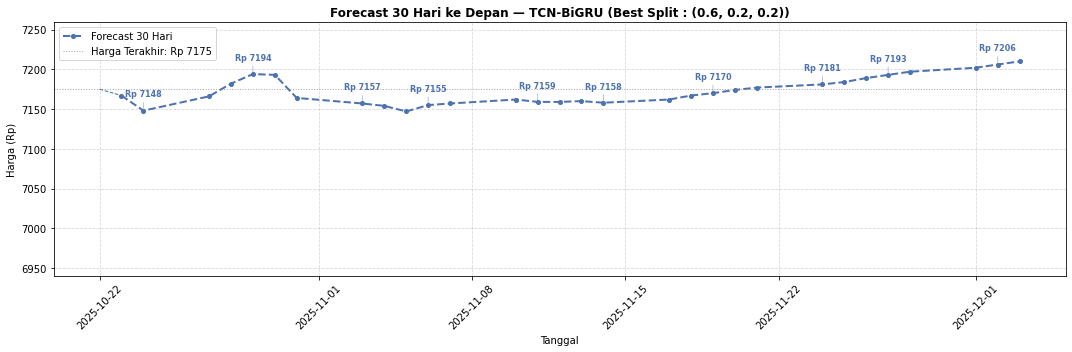

TCN-BiGRU
  Forecast Hari ke-1  : Rp 7167
  Forecast Hari ke-30 : Rp 7210



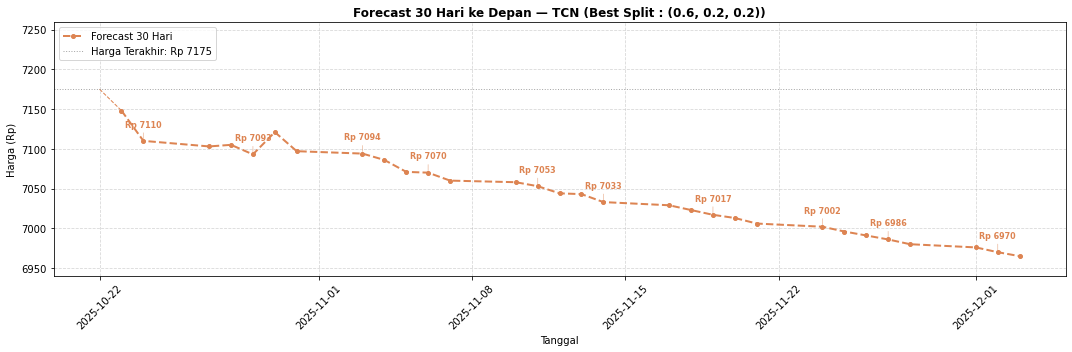

TCN
  Forecast Hari ke-1  : Rp 7148
  Forecast Hari ke-30 : Rp 6965



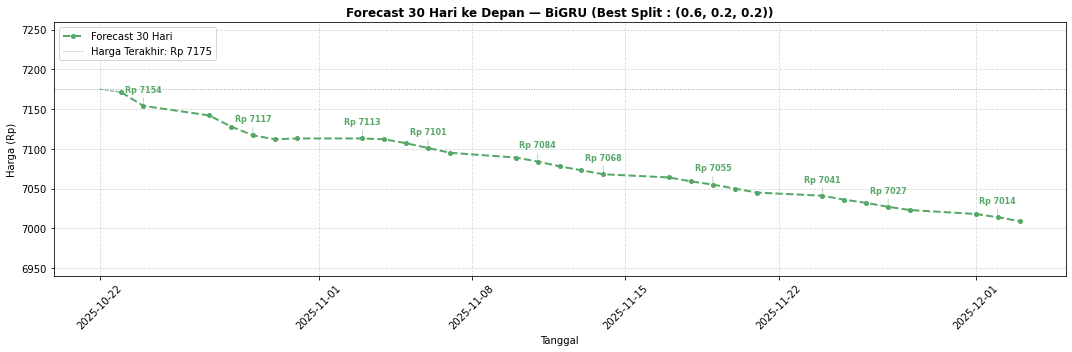

BiGRU
  Forecast Hari ke-1  : Rp 7171
  Forecast Hari ke-30 : Rp 7009



In [320]:
# =============================================================
# FORECAST 30 HARI DENGAN SUMBU Y DISERAGAMKAN
# =============================================================

forecast_data = [
    ("TCN-BiGRU",  forecast_30_tcn_bigru, colors[0], best_splits["TCN-BiGRU"]),
    ("TCN",   forecast_30_tcn,        colors[1], best_splits["TCN"]),
    ("BiGRU", forecast_30_bigru,      colors[2], best_splits["BiGRU"]),
]

# 1. CARI MIN & MAX GLOBAL UNTUK SEMUA MODEL
# Masukkan juga harga terakhir (last_actual_price) agar tidak terpotong
all_forecast_values = [last_actual_price]
for _, forecast_prices, _, _ in forecast_data:
    all_forecast_values.extend(forecast_prices)

y_min_global = min(all_forecast_values)
y_max_global = max(all_forecast_values)

# Tambahkan padding (misal 10%) agar anotasi teks tidak menabrak atap grafik
y_range = y_max_global - y_min_global
y_limit_lower = y_min_global - (y_range * 0.1)
y_limit_upper = y_max_global + (y_range * 0.2) 

# 2. LOOPING PLOT DENGAN SKALA YANG SAMA
for model_name, forecast_prices, color, best_split in forecast_data:
    fig, ax = plt.subplots(figsize=(15, 5))

    # Garis penghubung dari harga terakhir ke forecast hari ke-1
    ax.plot([last_actual_date, forecast_dates[0]],
            [last_actual_price, forecast_prices[0]],
            color=color, linestyle='--', linewidth=1)

    # Line forecast 30 hari
    ax.plot(forecast_dates, forecast_prices,
            label='Forecast 30 Hari', color=color,
            linestyle='--', linewidth=2, marker='o', markersize=4)

    # Anotasi harga tiap beberapa hari
    for j in [1, 4, 7, 10, 13, 16, 19, 22, 25, 28]:
        price = forecast_prices[j]
        date  = forecast_dates[j]
        ax.annotate(
            f"Rp {price:.0f}",
            xy=(date, price),
            xytext=(0, 14),
            textcoords="offset points",
            ha='center',
            fontsize=8,
            color=color,
            fontweight='bold',
            arrowprops=dict(arrowstyle='-', color=color, lw=0.8, alpha=0.5)
        )

    # Garis referensi harga terakhir
    ax.axhline(y=last_actual_price, color='gray', linestyle=':', linewidth=1,
               alpha=0.7, label=f'Harga Terakhir: Rp {last_actual_price:.0f}')

    # --- KUNCI: Set skala sumbu Y agar sama di semua grafik ---
    ax.set_ylim(y_limit_lower, y_limit_upper)

    ax.set_title(f"Forecast 30 Hari ke Depan — {model_name} (Best Split : {best_split})",
                 fontsize=12, fontweight='bold')
    ax.set_xlabel("Tanggal")
    ax.set_ylabel("Harga (Rp)")
    ax.legend(loc='upper left') # Pindah posisi legend agar tidak menutupi garis
    ax.grid(linestyle='--', alpha=0.5)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    print(f"{model_name}")
    print(f"  Forecast Hari ke-1  : Rp {forecast_prices[0]:.0f}")
    print(f"  Forecast Hari ke-30 : Rp {forecast_prices[-1]:.0f}\n")

TABEL FORECAST 30 HARI LENGKAP

In [321]:
forecast_dates = pd.to_datetime(tcn_bigru["forecast_30_dates"])

df_forecast_all = pd.DataFrame({
    "Hari Ke-":    range(1, 31),
    "Tanggal":     [d.strftime('%Y-%m-%d') for d in forecast_dates],
    "TCN-BiGRU (Rp)":  [round(v, 3) for v in tcn_bigru["forecast_30_prices"]],
    "TCN (Rp)":   [round(v, 3) for v in tcn["forecast_30_prices"]],
    "BiGRU (Rp)": [round(v, 3) for v in bigru["forecast_30_prices"]],
})

print("=" * 60)
print("TABEL FORECAST 30 HARI — SEMUA MODEL")
print("=" * 60)
display(df_forecast_all)

TABEL FORECAST 30 HARI — SEMUA MODEL


,Hari Ke-,Tanggal,TCN-BiGRU (Rp),TCN (Rp),BiGRU (Rp)
0,1,2025-10-23,7167,7148,7171
1,2,2025-10-24,7148,7110,7154
2,3,2025-10-27,7166,7103,7142
3,4,2025-10-28,7182,7105,7128
4,5,2025-10-29,7194,7093,7117
5,6,2025-10-30,7193,7121,7112
6,7,2025-10-31,7164,7097,7113
7,8,2025-11-03,7157,7094,7113
8,9,2025-11-04,7154,7086,7112
9,10,2025-11-05,7147,7071,7107


CHART FORECAST 30 HARI (3 model dalam 1 plot)

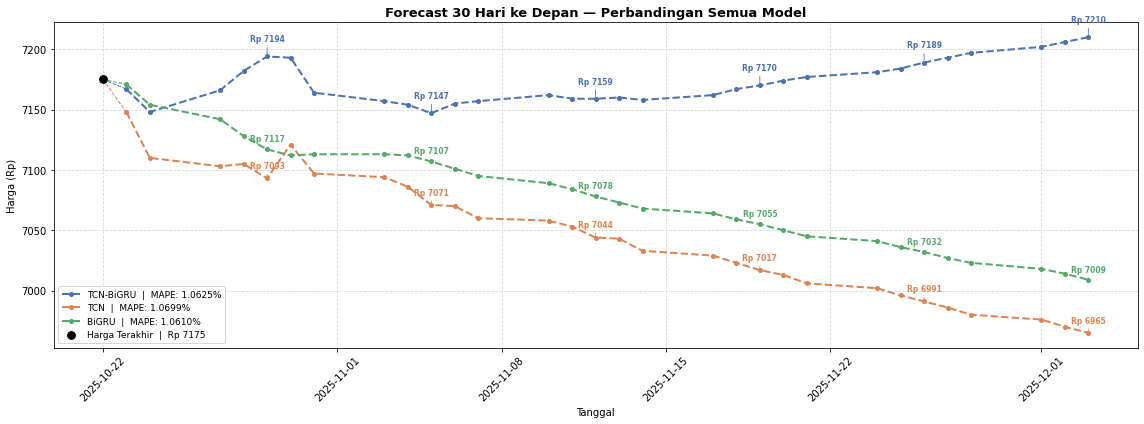

In [322]:
last_actual_price = tcn_bigru["last_actual_price"]
last_actual_date  = pd.to_datetime(tcn_bigru["last_actual_date"])

fig, ax = plt.subplots(figsize=(16, 6))

for i, (model_name, pkl, color) in enumerate([
    ("TCN-BiGRU",  tcn_bigru, colors[0]),
    ("TCN",   tcn,       colors[1]),
    ("BiGRU", bigru,     colors[2]),
]):
    prices = pkl["forecast_30_prices"]
    dates  = pd.to_datetime(pkl["forecast_30_dates"])
    mape   = pkl["mape"]

    # Garis dari harga terakhir ke hari ke-1
    ax.plot([last_actual_date, dates[0]],
            [last_actual_price, prices[0]],
            color=color, linestyle='--', linewidth=1)

    # Line forecast — label sekarang include MAPE
    ax.plot(dates, prices,
            label=f"{model_name}  |  MAPE: {mape:.4f}%",
            color=color, linestyle='--', linewidth=2,
            marker='o', markersize=4)

    # Anotasi harga tiap 5 hari (hari ke-5, 10, 15, 20, 25, 30)
    for j, (date, price) in enumerate(zip(dates, prices)):
        if (j + 1) % 5 == 0:  # hari ke-5, 10, 15, 20, 25, 30
            # offset vertikal beda tiap model biar tidak tumpuk
            offset = [15, 10, 8][i]
            ax.annotate(
                f"Rp {price:.0f}",
                xy=(date, price),
                xytext=(0, offset),
                textcoords="offset points",
                ha='center',
                fontsize=7.5,
                color=color,
                fontweight='bold',
                arrowprops=dict(arrowstyle='-', color=color, lw=0.8)
            )

# Titik aktual terakhir
ax.scatter(last_actual_date, last_actual_price,
           color='black', zorder=5, s=60,
           label=f'Harga Terakhir  |  Rp {last_actual_price:.0f}')

ax.set_title("Forecast 30 Hari ke Depan — Perbandingan Semua Model",
             fontsize=13, fontweight='bold')
ax.set_xlabel("Tanggal")
ax.set_ylabel("Harga (Rp)")
ax.legend(loc='best', fontsize=9)
ax.grid(linestyle='--', alpha=0.5)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

tambahkan visualisasinya pake data actual (testingnya aja)

KESIMPULAN

In [323]:
models_list = ["TCN-BiGRU", "TCN", "BiGRU"]
pkls        = [tcn_bigru, tcn, bigru]

mapes   = [p["mape"]  for p in pkls]
maes    = [p["mae"]   for p in pkls]
rmses   = [p["rmse"]  for p in pkls]
r2s     = [p["r2"]    for p in pkls]
times   = [p["total_time"] for p in pkls]
h1s     = [p["forecast_h1"] for p in pkls]

best_mape  = models_list[mapes.index(min(mapes))]
best_mae   = models_list[maes.index(min(maes))]
best_rmse  = models_list[rmses.index(min(rmses))]
best_r2    = models_list[r2s.index(max(r2s))]
best_time  = models_list[times.index(min(times))]
highest_h1 = models_list[h1s.index(max(h1s))]
lowest_h1  = models_list[h1s.index(min(h1s))]

mape_hybrid  = tcn_bigru["mape"]
mape_tcn     = tcn["mape"]
time_hybrid  = tcn_bigru["total_time"]
time_tcn     = tcn["total_time"]
mape_gap     = abs(mape_hybrid - mape_tcn)
time_gap     = abs(time_hybrid - time_tcn)

# Model terbaik overall: MAPE terkecil + R² terbesar (skor gabungan)
# Normalisasi: MAPE makin kecil makin baik, R² makin besar makin baik
import numpy as np
mape_norm = [(m - min(mapes)) / (max(mapes) - min(mapes)) if max(mapes) != min(mapes) else 0 for m in mapes]
r2_norm   = [(max(r2s) - r) / (max(r2s) - min(r2s)) if max(r2s) != min(r2s) else 0 for r in r2s]
scores    = [m + r for m, r in zip(mape_norm, r2_norm)]  # makin kecil makin baik
best_overall = models_list[scores.index(min(scores))]

print("=" * 60)
print("📋 KESIMPULAN PERBANDINGAN MODEL")
print("=" * 60)
print(f"1. 🏆 MAPE terbaik (terendah)    : {best_mape.ljust(12)} ({min(mapes):.4f}%)")
print(f"2. 📉 RMSE terkecil              : {best_rmse.ljust(12)} ({min(rmses):.4f})")
print(f"3. 📏 MAE terkecil               : {best_mae.ljust(12)} ({min(maes):.4f})")
print(f"4. 📈 R² terbesar                : {best_r2.ljust(12)} ({max(r2s):.4f})")
print(f"5. ⚡ Training time tercepat      : {best_time.ljust(12)} ({min(times):.2f} detik)")
print(f"6. 📊 Forecast H+1 tertinggi     : {highest_h1.ljust(12)} (Rp {max(h1s):.3f})")
print(f"7. 📊 Forecast H+1 terendah      : {lowest_h1.ljust(12)} (Rp {min(h1s):.3f})")
print(f"8. 🥇 Model terbaik keseluruhan  : {best_overall.ljust(12)}")
if best_mape == best_rmse == best_r2:
    print(f"9. ✅ Model {best_mape} konsisten terbaik di MAPE, RMSE, dan R²")
else:
    print(f"9. ⚠️  Tidak ada model yang dominan di semua metrik sekaligus")
if best_mape == best_time:
    print(f"10. ✅ {best_mape} unggul di akurasi sekaligus training tercepat")
else:
    print(f"10. ⚖️  Trade-off: akurasi terbaik={best_mape}, tercepat={best_time}")
mape_gap = max(mapes) - min(mapes)
print(f"11. 📐 Selisih MAPE terbesar-terkecil : {mape_gap:.4f}%")
if mape_gap < 0.5:
    print(f"     → Perbedaan antar model sangat kecil (<0.5%), performa relatif setara")
elif mape_gap < 2:
    print(f"     → Perbedaan antar model moderat")
else:
    print(f"     → Perbedaan antar model cukup signifikan")
print("=" * 60)
for name, h1 in zip(models_list, h1s):
    arah = "naik ↑" if h1 > last_actual_price else "turun ↓"
    selisih = abs(h1 - last_actual_price)
    # Contoh output yang lebih rapi
    print(f"{name.ljust(12)} Forecast: Rp {int(h1):.0f} | Arah: {arah} (Selisih: Rp {selisih:.0f})")
print("=" * 60)
# if best_mape != best_rmse:
#     print(f"TCN unggul MAPE & MAE, tapi BiGRU unggul RMSE & R²")
#     print(f"TCN lebih baik di error rata-rata harian")
#     print(f"BiGRU lebih baik menangani lonjakan error ekstrem")
# print("=" * 60)
# print(f"🤔 Apakah TCN-BiGRU masih relevan?")
# print(f"     MAPE TCN-BiGRU : {mape_hybrid:.4f}%")
# print(f"     MAPE TCN       : {mape_tcn:.4f}%")
# print(f"     Selisih MAPE   : {mape_gap:.4f}%")
# print(f"     Selisih waktu  : {time_gap:.2f} detik atau {time_gap/60:.2f} menit lebih lama")

# if mape_gap < 0.5 and time_hybrid > time_tcn:
#     print(f"TCN-BiGRU TIDAK signifikan lebih baik dari TCN,")
#     print(f"sementara membutuhkan {time_gap:.2f} detik atau {time_gap/60:.2f} menit lebih lama.")
#     print(f"Untuk kasus ini, TCN lebih direkomendasikan")
#     print(f"karena lebih efisien tanpa kehilangan akurasi berarti.")
# elif mape_hybrid < mape_tcn and mape_gap >= 0.5:
#     print(f"TCN-BiGRU terbukti lebih akurat secara signifikan (>{0.5}%),")
#     print(f"kompleksitas tambahan BiGRU memberikan manfaat nyata.")
# elif mape_hybrid > mape_tcn:
#     print(f"TCN bahkan lebih akurat dari TCN-BiGRU.")
#     print(f"Penambahan BiGRU tidak memberikan manfaat pada dataset ini.")
# print("=" * 60)

📋 KESIMPULAN PERBANDINGAN MODEL
1. 🏆 MAPE terbaik (terendah)    : BiGRU        (1.0610%)
2. 📉 RMSE terkecil              : BiGRU        (107.6649)
3. 📏 MAE terkecil               : BiGRU        (76.2405)
4. 📈 R² terbesar                : BiGRU        (0.9783)
5. ⚡ Training time tercepat      : TCN          (1190.96 detik)
6. 📊 Forecast H+1 tertinggi     : BiGRU        (Rp 7171.731)
7. 📊 Forecast H+1 terendah      : TCN          (Rp 7148.628)
8. 🥇 Model terbaik keseluruhan  : BiGRU       
9. ✅ Model BiGRU konsisten terbaik di MAPE, RMSE, dan R²
10. ⚖️  Trade-off: akurasi terbaik=BiGRU, tercepat=TCN
11. 📐 Selisih MAPE terbesar-terkecil : 0.0090%
     → Perbedaan antar model sangat kecil (<0.5%), performa relatif setara
TCN-BiGRU    Forecast: Rp 7167 | Arah: turun ↓ (Selisih: Rp 8)
TCN          Forecast: Rp 7148 | Arah: turun ↓ (Selisih: Rp 26)
BiGRU        Forecast: Rp 7171 | Arah: turun ↓ (Selisih: Rp 3)


TABEL PERBANDINGAN MAPE PER SPLIT PER ALGORITMA


,Split,MAPE TCN (%),MAPE BiGRU (%),MAPE TCN-BiGRU (%)
0,60/20/20,1.0699,1.0610,1.0625
1,70/15/15,1.2048,1.1805,1.1743
2,80/10/10,1.3229,1.3046,1.3131


TABEL PARAMETER TERBAIK PER SPLIT PER ALGORITMA


,Split,Params TCN,Params BiGRU,Params TCN-BiGRU
0,60/20/20,"(64, 3, (1, 2, 4), 0.2, 32, 0.0001)","(16, 0.1, 16, 0.001)","(32, 5, (1, 2, 4), 64, 0.2, 32, 0.0001)"
1,70/15/15,"(64, 3, (1, 2, 4), 0.2, 16, 0.001)","(64, 0.2, 16, 0.001)","(64, 3, (1, 2, 4), 64, 0.2, 16, 0.0001)"
2,80/10/10,"(32, 5, (1, 2, 4), 0.2, 32, 0.001)","(64, 0.3, 8, 0.001)","(64, 5, (1, 2, 4), 64, 0.2, 16, 0.001)"


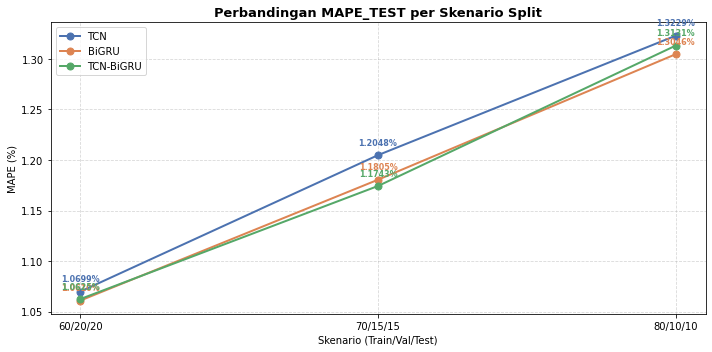

💡 INSIGHT ANALISIS PER SPLIT

📌 TCN
   MAPE per split : 1.0699% → 1.2048% → 1.3229%
   Trend          : meningkat ↑ seiring bertambahnya data train
   Skenario terbaik  : 60/20/20 (MAPE 1.0699%)

📌 BiGRU
   MAPE per split : 1.0610% → 1.1805% → 1.3046%
   Trend          : meningkat ↑ seiring bertambahnya data train
   Skenario terbaik  : 60/20/20 (MAPE 1.0610%)

📌 TCN-BiGRU
   MAPE per split : 1.0625% → 1.1743% → 1.3131%
   Trend          : meningkat ↑ seiring bertambahnya data train
   Skenario terbaik  : 60/20/20 (MAPE 1.0625%)

📊 Perbandingan antar algoritma per split:
   Skenario 60/20/20 → Terbaik: BiGRU (1.0610%), Terburuk: TCN (1.0699%)
   Skenario 70/15/15 → Terbaik: TCN-BiGRU (1.1743%), Terburuk: TCN (1.2048%)
   Skenario 80/10/10 → Terbaik: BiGRU (1.3046%), Terburuk: TCN (1.3229%)


In [324]:
import pickle
import pandas as pd

tcn_bigru = pickle.load(open("results_tcn_bigru.pkl", "rb"))
tcn       = pickle.load(open("results_tcn.pkl", "rb"))
bigru     = pickle.load(open("results_bigru.pkl", "rb"))

# ===============================
# ANALISIS PER SPLIT — PERBANDINGAN ANTAR ALGO
# ===============================
split_labels = ["0.6-0.2-0.2", "0.7-0.15-0.15", "0.8-0.1-0.1"]
split_display = ["60/20/20", "70/15/15", "80/10/10"]
colors = ["#4C72B0", "#DD8452", "#55A868"]
algo_names = ["TCN", "BiGRU", "TCN-BiGRU"]
algo_pkls  = [tcn, bigru, tcn_bigru]

# ===============================
# SUSUN DATA PER SPLIT PER ALGO
# ===============================
split_data = []
for split_label, split_disp in zip(split_labels, split_display):
    row = {"Split": split_disp}
    for algo_name, pkl in zip(algo_names, algo_pkls):
        match = next((r for r in pkl["all_results"] if r["split"] == split_label), None)
        if match:
            row[f"MAPE {algo_name} (%)"]  = round(match["best_mape"], 4)
            row[f"Time {algo_name} (dtk)"] = round(match["training_time_sec"], 2)
            row[f"Params {algo_name}"]     = str(match["best_params"])
    split_data.append(row)

df_split = pd.DataFrame(split_data)

# ===============================
# TABEL: MAPE per Split per Algo
# ===============================
print("=" * 70)
print("TABEL PERBANDINGAN MAPE PER SPLIT PER ALGORITMA")
print("=" * 70)
df_mape_split = df_split[["Split"] + [f"MAPE {a} (%)" for a in algo_names]]
display(df_mape_split)

# ===============================
# TABEL: PARAMETER per Split per Algo
# ===============================
print("=" * 70)
print("TABEL PARAMETER TERBAIK PER SPLIT PER ALGORITMA")
print("=" * 70)
df_params_split = df_split[["Split"] + [f"Params {a}" for a in algo_names]]
display(df_params_split)

# ===============================
# GRAFIK: MAPE per Split (line chart — trend naik/turun)
# ===============================
fig, ax = plt.subplots(figsize=(10, 5))

for algo_name, color in zip(algo_names, colors):
    mapes_per_split = [row[f"MAPE {algo_name} (%)"] for row in split_data]
    ax.plot(split_display, mapes_per_split,
            label=algo_name, color=color,
            linewidth=2, marker='o', markersize=7)
    # Anotasi nilai di tiap titik
    for x, y_val in zip(split_display, mapes_per_split):
        ax.annotate(f"{y_val:.4f}%",
                    xy=(x, y_val),
                    xytext=(0, 10),
                    textcoords="offset points",
                    ha='center', fontsize=8,
                    color=color, fontweight='bold')

ax.set_title("Perbandingan MAPE_TEST per Skenario Split", fontsize=13, fontweight='bold')
ax.set_xlabel("Skenario (Train/Val/Test)")
ax.set_ylabel("MAPE (%)")
ax.legend()
ax.grid(linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# ===============================
# INSIGHT OTOMATIS
# ===============================
print("=" * 60)
print("💡 INSIGHT ANALISIS PER SPLIT")
print("=" * 60)

for algo_name in algo_names:
    mapes_per_split = [row[f"MAPE {algo_name} (%)"] for row in split_data]
    best_split_idx  = mapes_per_split.index(min(mapes_per_split))
    trend = "menurun ↓" if mapes_per_split[-1] < mapes_per_split[0] else "meningkat ↑"

    print(f"\n📌 {algo_name}")
    print(f"   MAPE per split : {' → '.join([f'{m:.4f}%' for m in mapes_per_split])}")
    print(f"   Trend          : {trend} seiring bertambahnya data train")
    print(f"   Skenario terbaik  : {split_display[best_split_idx]} (MAPE {min(mapes_per_split):.4f}%)")

# Insight antar algo per split
print(f"\n📊 Perbandingan antar algoritma per split:")
for row, split_disp in zip(split_data, split_display):
    mapes = {a: row[f"MAPE {a} (%)"] for a in algo_names}
    best_algo = min(mapes, key=mapes.get)
    worst_algo = max(mapes, key=mapes.get)
    print(f"   Skenario {split_disp} → Terbaik: {best_algo} ({mapes[best_algo]:.4f}%), "
          f"Terburuk: {worst_algo} ({mapes[worst_algo]:.4f}%)")

print("=" * 60)

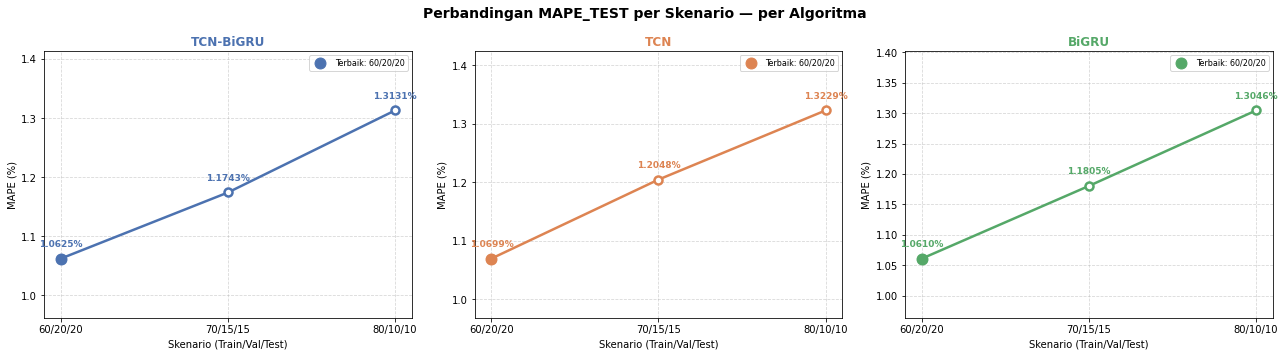

In [325]:
# ===============================
# GRAFIK MAPE PER SPLIT — 3 SUBPLOT (1 per algo)
# ===============================
split_labels  = ["0.6-0.2-0.2", "0.7-0.15-0.15", "0.8-0.1-0.1"]
split_display = ["60/20/20", "70/15/15", "80/10/10"]
algo_names    = ["TCN-BiGRU", "TCN", "BiGRU"]
algo_pkls     = [tcn_bigru, tcn, bigru]
colors        = ["#4C72B0", "#DD8452", "#55A868"]

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=False)
fig.suptitle("Perbandingan MAPE_TEST per Skenario — per Algoritma",
             fontsize=14, fontweight='bold')

for ax, algo_name, pkl, color in zip(axes, algo_names, algo_pkls, colors):
    mapes = []
    for split_label in split_labels:
        match = next((r for r in pkl["all_results"] if r["split"] == split_label), None)
        mapes.append(round(match["best_mape"], 4) if match else None)

    ax.plot(split_display, mapes,
            color=color, linewidth=2.5,
            marker='o', markersize=8, markerfacecolor='white',
            markeredgewidth=2.5, markeredgecolor=color)

    # Anotasi nilai di tiap titik
    for x, y_val in zip(split_display, mapes):
        if y_val is not None:
            ax.annotate(f"{y_val:.4f}%",
                        xy=(x, y_val),
                        xytext=(0, 12),
                        textcoords="offset points",
                        ha='center', fontsize=9,
                        color=color, fontweight='bold')

    # Highlight titik terbaik (MAPE terkecil)
    best_idx = mapes.index(min(m for m in mapes if m is not None))
    ax.scatter(split_display[best_idx], mapes[best_idx],
               color=color, s=120, zorder=5,
               label=f"Terbaik: {split_display[best_idx]}")

    ax.set_title(algo_name, fontsize=12, fontweight='bold', color=color)
    ax.set_xlabel("Skenario (Train/Val/Test)")
    ax.set_ylabel("MAPE (%)")
    ax.legend(fontsize=8)
    ax.grid(linestyle='--', alpha=0.5)

    # Batas Y sedikit lebih lebar dari range data
    y_min = min(m for m in mapes if m is not None)
    y_max = max(m for m in mapes if m is not None)
    margin = (y_max - y_min) * 0.4 if y_max != y_min else 0.1
    ax.set_ylim(y_min - margin, y_max + margin)

plt.tight_layout()
plt.show()

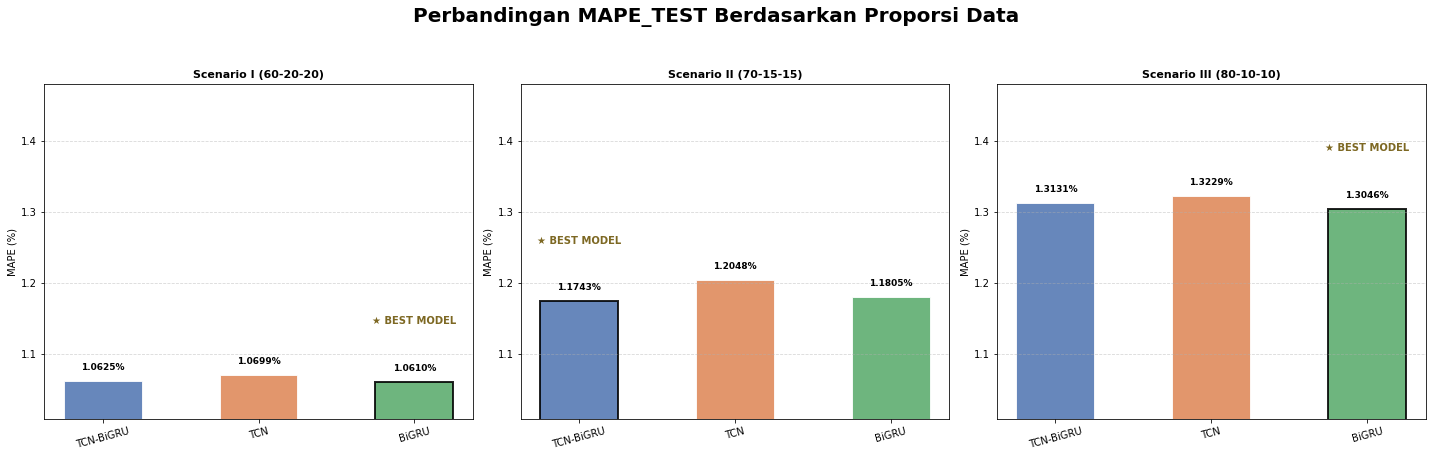

In [326]:
# =============================================================
# MAPE PER SCENARIO SPLIT
# =============================================================
split_labels  = ["0.6-0.2-0.2", "0.7-0.15-0.15", "0.8-0.1-0.1"]
split_titles  = ["Scenario I (60-20-20)", "Scenario II (70-15-15)", "Scenario III (80-10-10)"]
models        = ["TCN-BiGRU", "TCN", "BiGRU"]
colors        = ["#4C72B0", "#DD8452", "#55A868"]
width         = 0.5

# Menyiapkan data mape per split untuk looping
split_info = []
all_mape_values = [] # Untuk mencari min/max global

for label, title in zip(split_labels, split_titles):
    mape_values = []
    for pkl in [tcn_bigru, tcn, bigru]:
        match = next((r for r in pkl["all_results"] if r["split"] == label), None)
        val = match["best_mape"] if match else 0
        mape_values.append(val)
        all_mape_values.append(val)
    split_info.append((title, mape_values))

# --- HITUNG SKALA Y GLOBAL ---
global_min = min(all_mape_values)
global_max = max(all_mape_values)
global_range = global_max - global_min
y_limit_lower = global_min - (global_range * 0.2)
y_limit_upper = global_max + (global_range * 0.6) # Ruang ekstra untuk bintang gold

# Membuat Figure dengan 3 Subplot
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle("Perbandingan MAPE_TEST Berdasarkan Proporsi Data", fontsize=20, fontweight='bold', y=1.05)

for ax, (title, values) in zip(axes, split_info):
    # Plot Bar
    bars = ax.bar(models, values, color=colors, alpha=0.85, edgecolor='white', width=width)
    
    # Styling Subplot
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_ylabel("MAPE (%)")
    
    # Atur skala Y disamakan untuk semua subplot
    ax.set_ylim(y_limit_lower, y_limit_upper)
    
    ax.grid(axis='y', linestyle='--', alpha=0.5)
    ax.tick_params(axis='x', rotation=15)

    # Cari nilai terkecil (Best) untuk skenario ini
    min_mape = min(values)

    # Anotasi angka dan Label ★ BEST MODEL (Gold)
    for bar, val in zip(bars, values):
        # Tampilkan angka MAPE di atas setiap bar
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + (global_range * 0.05),
                f"{val:.4f}%", ha='center', va='bottom', fontsize=9, fontweight='bold')
        
        # Logika khusus untuk MAPE paling kecil (Best Performance)
        if val == min_mape:
            bar.set_edgecolor('black')
            bar.set_linewidth(2)
            
            # Tambahkan teks ★ BEST MODEL dengan warna Gold (#7D6823)
            ax.text(bar.get_x() + bar.get_width()/2,
                    bar.get_height() + (global_range * 0.3),
                    "★ BEST MODEL", 
                    ha='center', va='bottom', 
                    fontsize=10, fontweight='bold', color='#7D6823')

plt.tight_layout()
plt.show()

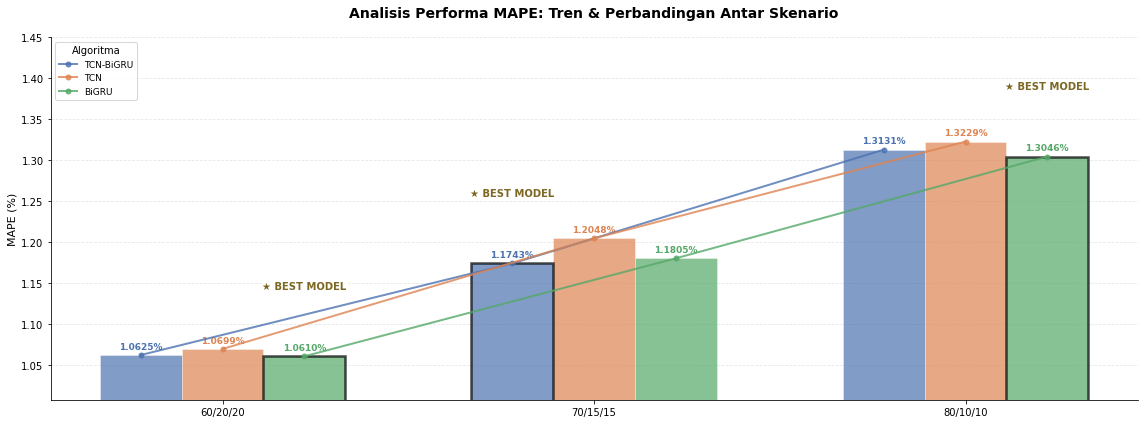

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Membersihkan sisa plot agar kanvas tidak menumpuk
plt.close('all')

# 1. Perkecil tinggi figsize agar tidak 'melar' ke bawah
fig, ax = plt.subplots(figsize=(16, 6))

# Ekstraksi data
all_data = []
for pkl in algo_pkls:
    mape_algo = []
    for split in split_labels:
        match = next((r for r in pkl["all_results"] if r["split"] == split), None)
        mape_algo.append(match["best_mape"] if match else 0)
    all_data.append(mape_algo)

x = np.arange(len(split_display))
width = 0.22 

# --- MODIFIKASI: Gambar Bar & Line Tren ---
for i, (name, color) in enumerate(zip(algo_names, colors)):
    pos = x + (i * width) - width
    
    # Render Bar satu per satu untuk kontrol highlight model terbaik per skenario
    for j, (p, val) in enumerate(zip(pos, all_data[i])):
        # Cek apakah ini model terbaik di skenario split ke-j
        current_split_mapes = [all_data[a_idx][j] for a_idx in range(len(algo_names))]
        is_best = (val == min(current_split_mapes))
        
        # Highlight best model dengan garis pinggir hitam tebal
        edge_c = 'black' if is_best else 'white'
        line_w = 2.5 if is_best else 0.5
        z_ord = 3 if is_best else 2
        
        bar_obj = ax.bar(p, val, width, color=color, alpha=0.7, 
                         edgecolor=edge_c, linewidth=line_w, zorder=z_ord)
        
        # Tambahkan teks MAPE di atas bar
        ax.text(p, val + 0.005, f'{val:.4f}%', ha='center', va='bottom', 
                fontsize=9, fontweight='bold', color=color)

    # Gambar Line Tren di belakang bar agar tetap terlihat jalurnya
    ax.plot(pos, all_data[i], color=color, marker='o', linewidth=2, 
            markersize=5, alpha=0.8, zorder=4, label=name if i==i else "")

# 2. Tambahkan Label ★ BEST MODEL (Gold)
for s_idx in range(len(split_display)):
    current_mapes = [all_data[a_idx][s_idx] for a_idx in range(len(algo_names))]
    min_val, max_val = min(current_mapes), max(current_mapes)
    best_algo_idx = current_mapes.index(min_val)
    best_x_pos = x[s_idx] + (best_algo_idx * width) - width
    
    # Offset y yang proporsional agar label tidak menabrak angka
    y_offset = 0.08 
    
    ax.text(best_x_pos, min_val + y_offset, 
            "★ BEST MODEL", ha='center', va='bottom', 
            fontsize=10, fontweight='black', color='#7D6823',
            bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=0.5))

# Kosmetik Plot
ax.set_title("Analisis Performa MAPE: Tren & Perbandingan Antar Skenario", fontsize=14, fontweight='bold', pad=20)
ax.set_ylabel("MAPE (%)", fontsize=11)
ax.set_xticks(x)
ax.set_xticklabels(split_display)
ax.legend(algo_names, title="Algoritma", loc='upper left', fontsize=9)

# Grid & Spines
ax.grid(axis='y', linestyle='--', alpha=0.3, zorder=1)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Kunci agar tidak kepanjangan
y_all = [val for sublist in all_data for val in sublist]
ax.set_ylim(min(y_all) * 0.95, 1.45) 

plt.tight_layout()
plt.show()

In [328]:
# ===============================
# LOAD TUNING DATA DARI PICKLE
# ===============================
df_tuning_tcn_bigru = pd.DataFrame(tcn_bigru["tuning_table_data"])
df_tuning_tcn       = pd.DataFrame(tcn["tuning_table_data"])
df_tuning_bigru     = pd.DataFrame(bigru["tuning_table_data"])

# Tambahkan kolom nama algo
df_tuning_tcn_bigru["Algo"] = "TCN-BiGRU"
df_tuning_tcn["Algo"]       = "TCN"
df_tuning_bigru["Algo"]     = "BiGRU"

# Gabungkan semua
df_all_tuning = pd.concat([df_tuning_tcn_bigru, df_tuning_tcn, df_tuning_bigru], ignore_index=True)

print("Kolom tersedia:", df_all_tuning.columns.tolist())
display(df_all_tuning.head(15))

Kolom tersedia: ['Kombinasi Ke-', 'Split', 'Filter', 'Kernel', 'GRU Units', 'Batch Size', 'LR', 'Best Epoch', 'MAPE (%)', 'Time (sec)', 'Algo']


,Kombinasi Ke-,Split,Filter,Kernel,GRU Units,Batch Size,LR,Best Epoch,MAPE (%),Time (sec),Algo
0,1,0.6-0.2-0.2,32.0,3.0,32.0,16,0.0010,22,1.1051,18.45,TCN-BiGRU
1,2,0.6-0.2-0.2,32.0,3.0,32.0,16,0.0001,36,1.2345,24.70,TCN-BiGRU
2,3,0.6-0.2-0.2,32.0,3.0,32.0,32,0.0010,21,1.1238,13.37,TCN-BiGRU
3,4,0.6-0.2-0.2,32.0,3.0,32.0,32,0.0001,59,1.2013,23.09,TCN-BiGRU
4,5,0.6-0.2-0.2,32.0,3.0,32.0,16,0.0010,11,1.2291,13.77,TCN-BiGRU
5,6,0.6-0.2-0.2,32.0,3.0,32.0,16,0.0001,1,2.7817,8.81,TCN-BiGRU
6,7,0.6-0.2-0.2,32.0,3.0,32.0,32,0.0010,32,1.1048,18.00,TCN-BiGRU
7,8,0.6-0.2-0.2,32.0,3.0,32.0,32,0.0001,13,1.7620,11.64,TCN-BiGRU
8,9,0.6-0.2-0.2,32.0,3.0,64.0,16,0.0010,14,1.1936,17.75,TCN-BiGRU
9,10,0.6-0.2-0.2,32.0,3.0,64.0,16,0.0001,28,1.1042,26.58,TCN-BiGRU


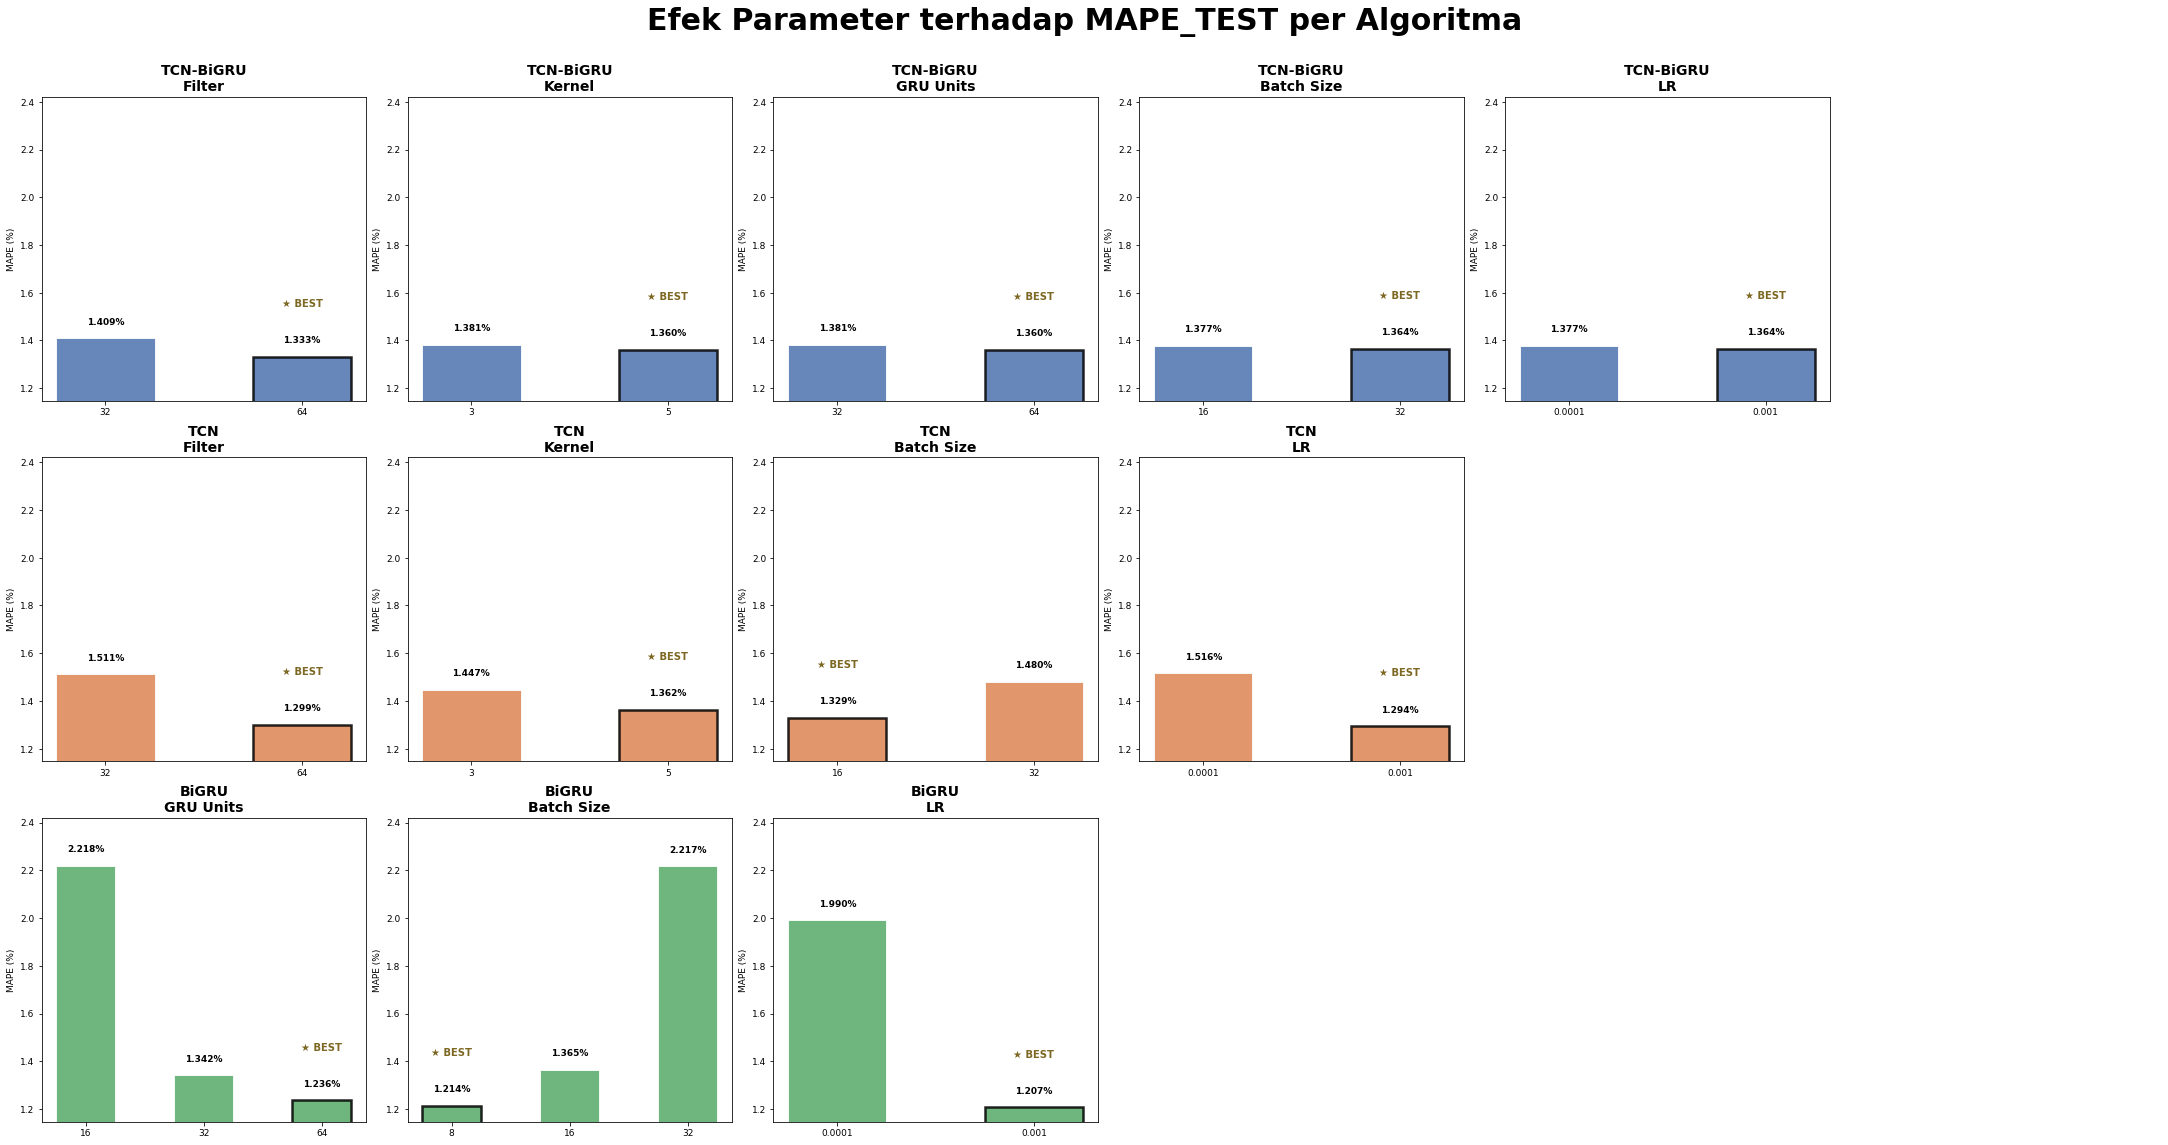

In [329]:
# ===============================
# 1. CARI RENTANG MAPE GLOBAL
# ===============================
all_mape_values = []
for algo_name, df_a in tuning_map.items():
    param_cols = param_cols_map[algo_name]
    for p in param_cols:
        all_mape_values.extend(df_a.groupby(p)["MAPE (%)"].mean().tolist())

# Kita ambil min dan max global untuk skala Y yang konsisten
global_mape_min = min(all_mape_values)
global_mape_max = max(all_mape_values)

# Tambahkan padding 40% di atas agar teks "★ BEST" tidak terpotong
y_limit_lower = global_mape_min * 0.95 
y_limit_upper = global_mape_max + (global_mape_max - global_mape_min) * 0.2

# ===============================
# 2. GRAFIK MAPE DENGAN SKALA SERAGAM
# ===============================
fig, axes = plt.subplots(n_rows, n_cols, figsize=(30, 15), layout='constrained')
fig.suptitle("Efek Parameter terhadap MAPE_TEST per Algoritma", 
             fontsize=30, fontweight='bold', y=1.05)

for row_idx, (algo_name, param_cols) in enumerate(param_cols_map.items()):
    df_a  = tuning_map[algo_name]
    color = color_map[algo_name]

    for col_idx in range(n_cols):
        ax = axes[row_idx][col_idx]

        if col_idx < len(param_cols):
            param   = param_cols[col_idx]
            grouped = df_a.groupby(param)["MAPE (%)"].mean().reset_index()

            bars = ax.bar(grouped[param].astype(str), grouped["MAPE (%)"],
                          color=color, alpha=0.85, edgecolor='white', width=0.5)

            # --- SET SKALA Y SERAGAM ---
            ax.set_ylim(y_limit_lower, y_limit_upper)
            
            # Rentang lokal untuk padding teks (opsional, bisa pakai global_range)
            global_range = global_mape_max - global_mape_min

            for bar, val in zip(bars, grouped["MAPE (%)"]):
                ax.text(bar.get_x() + bar.get_width()/2, 
                        val + (global_range * 0.05), 
                        f"{val:.3f}%", ha='center', va='bottom', 
                        fontsize=9, fontweight='bold')
                
            # --- LOGIKA BINTANG BEST MODEL ---
            best_idx = grouped["MAPE (%)"].idxmin()
            bars[best_idx].set_edgecolor('black')
            bars[best_idx].set_linewidth(2.5)
            
            ax.text(bars[best_idx].get_x() + bars[best_idx].get_width()/2, 
                    bars[best_idx].get_height() + (global_range * 0.2), 
                    "★ BEST", ha='center', va='bottom', 
                    fontsize=10, fontweight='bold', color="#7D6823")

            ax.set_title(f"{algo_name}\n{param}", fontsize=14, fontweight='bold')
            ax.set_ylabel("MAPE (%)", fontsize=9)
            ax.tick_params(axis='both', labelsize=9)

        else:
            ax.axis('off')

plt.show()

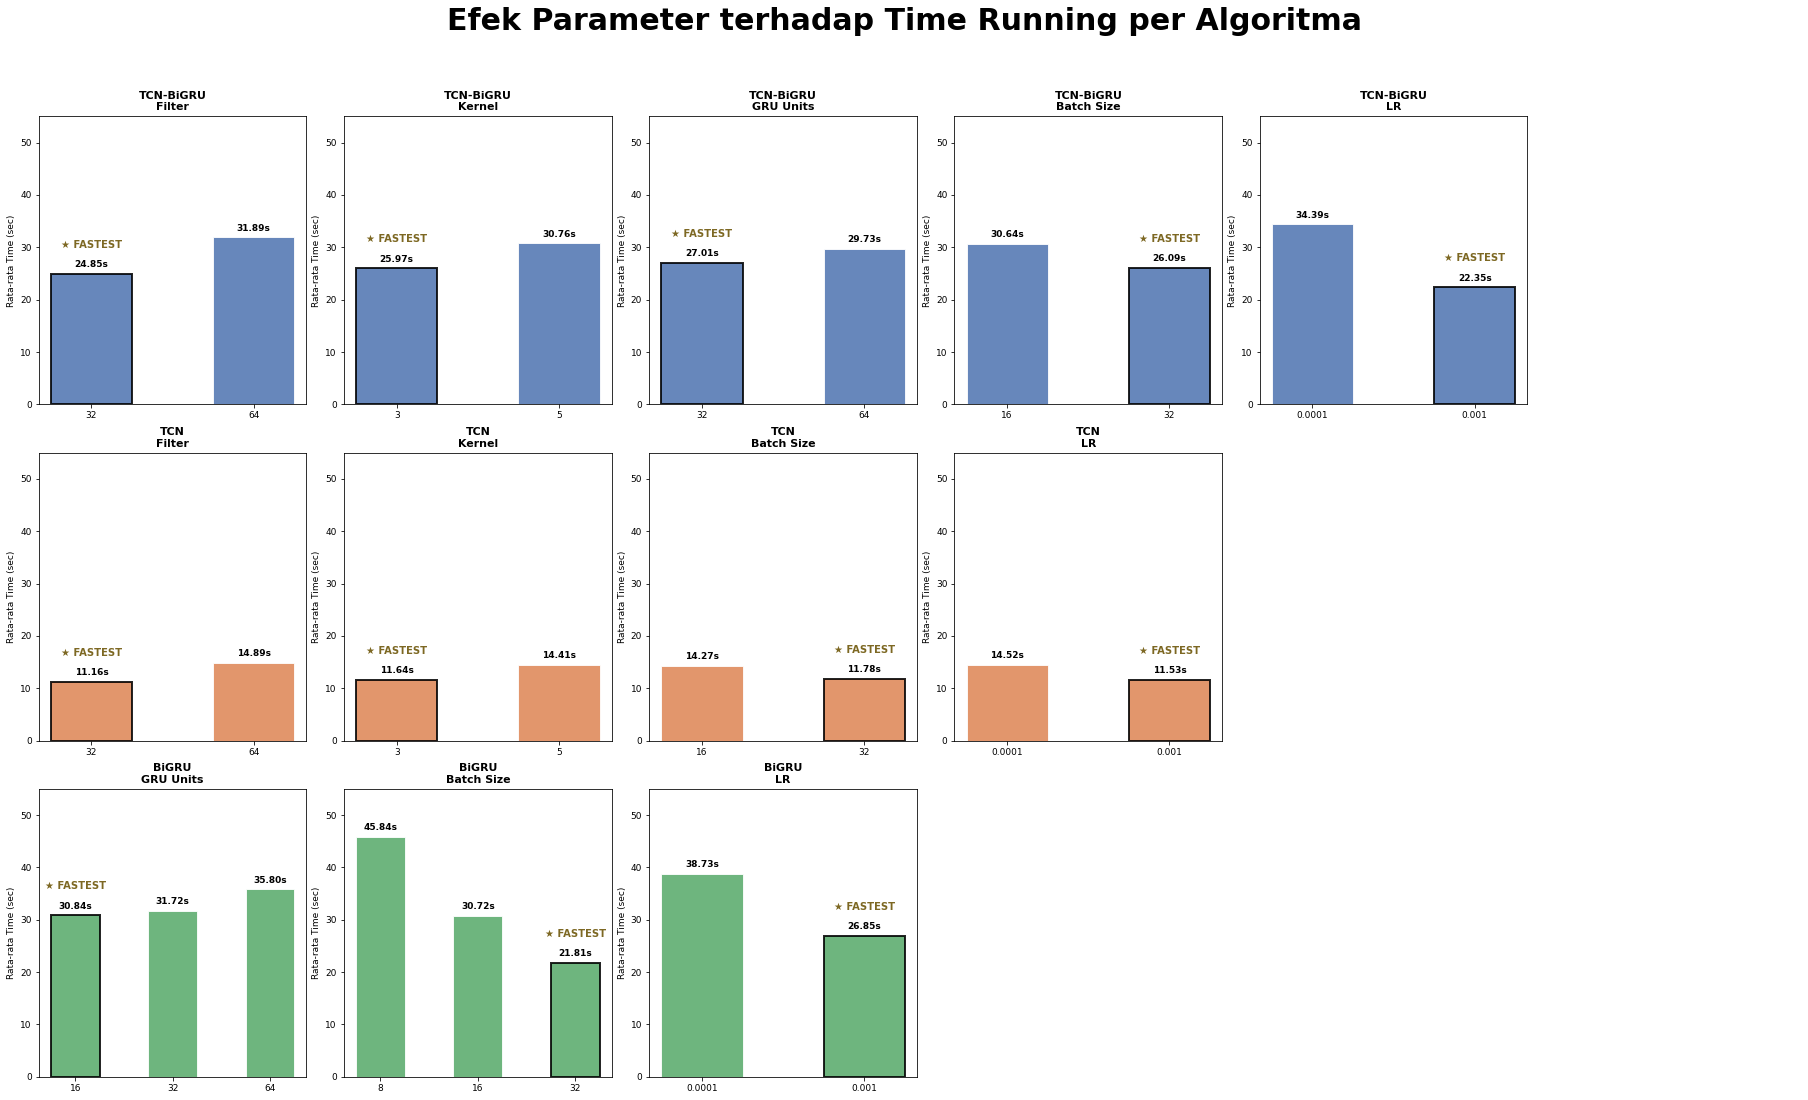

In [330]:
# ===============================
# 1. CARI NILAI MAKSIMUM GLOBAL
# ===============================
# Kumpulkan semua nilai rata-rata waktu dari semua dataframe di tuning_map
all_means = []
for algo_name, df_a in tuning_map.items():
    param_cols = param_cols_map[algo_name]
    for p in param_cols:
        # Hitung rata-rata tiap grup dan masukkan ke list
        all_means.extend(df_a.groupby(p)["Time (sec)"].mean().tolist())

# Tentukan batas atas (max dari semua rata-rata + padding 30% buat ruang teks/bintang)
global_max_time = max(all_means)
y_limit_upper = global_max_time * 1.2  # Memberi ruang di atas bar untuk label

# ===============================
# 2. PLOTTING DENGAN SKALA SERAGAM
# ===============================
fig, axes = plt.subplots(n_rows, n_cols, figsize=(25, 14), layout='constrained')
fig.suptitle("Efek Parameter terhadap Time Running per Algoritma",
             fontsize=30, fontweight='bold', y=1.08)

for row_idx, (algo_name, param_cols) in enumerate(param_cols_map.items()):
    df_a  = tuning_map[algo_name]
    color = color_map[algo_name]

    for col_idx in range(n_cols):
        ax = axes[row_idx][col_idx]

        if col_idx < len(param_cols):
            param   = param_cols[col_idx]
            grouped = df_a.groupby(param)["Time (sec)"].mean().reset_index()

            bars = ax.bar(grouped[param].astype(str), grouped["Time (sec)"],
                          color=color, alpha=0.85, edgecolor='white', width=0.5)

            # SET SKALA Y YANG SAMA UNTUK SEMUA SUBPLOT
            ax.set_ylim(0, y_limit_upper)

            # Gunakan global_max_time untuk menentukan posisi teks agar konsisten
            for bar, val in zip(bars, grouped["Time (sec)"]):
                ax.text(bar.get_x() + bar.get_width()/2,
                        val + (global_max_time * 0.02), 
                        f"{val:.2f}s", ha='center', va='bottom',
                        fontsize=9, fontweight='bold')

            # Highlight TERCEPAT
            best_idx = grouped["Time (sec)"].idxmin()
            bars[best_idx].set_edgecolor('black')
            bars[best_idx].set_linewidth(2)
            ax.text(bars[best_idx].get_x() + bars[best_idx].get_width()/2,
                    bars[best_idx].get_height() + (global_max_time * 0.1),
                    "★ FASTEST", ha='center', va='bottom',
                    fontsize=10, fontweight='bold', color="#7D6823")

            ax.set_title(f"{algo_name}\n{param}", fontsize=11, fontweight='bold')
            ax.set_ylabel("Rata-rata Time (sec)", fontsize=9)
            ax.tick_params(axis='both', labelsize=9)
        else:
            ax.axis('off')

plt.show()

In [331]:
# ===============================
# INSIGHT OTOMATIS PARAMETER
# ===============================
print("=" * 65)
print("💡 INSIGHT EFEK PARAMETER TERHADAP MAPE")
print("=" * 65)

for algo_name, df_a, param_cols in zip(
    ["TCN-BiGRU", "TCN", "BiGRU"],
    [df_tuning_tcn_bigru, df_tuning_tcn, df_tuning_bigru],
    [param_cols_map["TCN-BiGRU"], param_cols_map["TCN"], param_cols_map["BiGRU"]]
):
    print(f"\n📌 {algo_name}")
    for param in param_cols:
        grouped = df_a.groupby(param)["MAPE (%)"].mean()
        best_val  = grouped.idxmin()
        worst_val = grouped.idxmax()
        print(f"   {param.ljust(12)}: terbaik={best_val} ({grouped[best_val]:.4f}%), "
              f"terburuk={worst_val} ({grouped[worst_val]:.4f}%)")

print("=" * 65)

💡 INSIGHT EFEK PARAMETER TERHADAP MAPE

📌 TCN-BiGRU
   Filter      : terbaik=64 (1.3325%), terburuk=32 (1.4087%)
   Kernel      : terbaik=5 (1.3599%), terburuk=3 (1.3813%)
   GRU Units   : terbaik=64 (1.3603%), terburuk=32 (1.3810%)
   Batch Size  : terbaik=32 (1.3642%), terburuk=16 (1.3770%)
   LR          : terbaik=0.001 (1.3641%), terburuk=0.0001 (1.3771%)

📌 TCN
   Filter      : terbaik=64 (1.2988%), terburuk=32 (1.4625%)
   Kernel      : terbaik=5 (1.3385%), terburuk=3 (1.4228%)
   Batch Size  : terbaik=16 (1.3598%), terburuk=32 (1.4015%)
   LR          : terbaik=0.001 (1.2795%), terburuk=0.0001 (1.4818%)

📌 BiGRU
   GRU Units   : terbaik=64 (1.2357%), terburuk=16 (2.2178%)
   Batch Size  : terbaik=8 (1.2137%), terburuk=32 (2.2167%)
   LR          : terbaik=0.001 (1.2068%), terburuk=0.0001 (1.9900%)
